<a href="https://colab.research.google.com/github/jptrainor4-glitch/Data-Analytics/blob/main/Pedestrian_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [180]:
import pandas as pd
import os
from google.colab import files, drive
import matplotlib.pyplot as plt


uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, sep = ';')


    df_copy = df.copy

Saving pedestrian-counting-system-monthly-counts-per-hour.csv to pedestrian-counting-system-monthly-counts-per-hour (2).csv


In [177]:
df= df_copy

In [181]:
#Data cleaning, analysising and formating

df['location'] = df['location'].str.split(',')            #Split location column into indivdual strings

df['Latitude'] = df['location'].str[0].astype(float)      #Index first string, covert to float (removing spaces) and place in new Latitude column
df['Longitude'] = df['location'].str[1].astype(float)     #Index second string, covert to float (removing spaces) and place in new Longitude column

df = df.drop(columns = ['location'])                      #Drop location columns as both Latitue and Longitude are already containing the information

df['id'] = df['id'].astype(str)                           #Change typing of id column into string
df['location_id'] = df['location_id'].astype(str)         #Change location id column into string

df['sensing_date'] = pd.to_datetime(df['sensing_date'], errors='raise')         #Convert date column from str to date time d type


#Check time spane of data, duplicate values, and missing data
print(df['sensing_date'].min(), df['sensing_date'].max())                       #2024-10-03 2026-10-01
print('\n', df.duplicated(subset = ['location_id', 'sensing_date', 'hourday'], keep='first').sum())  #Check combination of columns to look for repeated entries
print('\n', df.isna().sum())                                                    #No missing values, no identical rows


#Ensure location ID is specific to geographical location and specific sensor name.
df_grouped = df.groupby('location_id').agg(                                     #Group df in individual location IDs
    latitude = ('Latitude', 'nunique'),                                         #Find all unique values in each column within location ID sub groups
    longitude = ('Longitude', 'nunique'),
    sen_name = ('sensor_name', 'nunique'))

print('\n', '# of Unique values by location ID (Min/Max)')
for col in df_grouped:
  print(col, df_grouped[col].min(), df_grouped[col].max())                      #Print the min and max amount of unique values in each grouped column
  #One sensor name and location per location id.

2024-10-03 00:00:00 2026-10-01 00:00:00

 0

 id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
Latitude           0
Longitude          0
dtype: int64

 # of Unique values by location ID (Min/Max)
latitude 1 1
longitude 1 1
sen_name 1 1


In [ ]:
#Checking data grouped by location ID, this gives informaiton on each senser and the amount of data it produces
df_grouped = df.groupby('location_id').agg(                                     #Group df in individual location IDs
    start_day = ('sensing_date', 'min'),                                        #When sensor began collecting data
    finish_day = ('sensing_date', 'max'),                                       #When sensor finished collecting data
    hours = ('hourday', 'count'),                                               #Amount of hours sensor collected data
    operating_day_count = ('sensing_date', 'nunique'))                          #Amount of days sensor collected data

df_grouped['total days'] = (df_grouped['finish_day'] - df_grouped['start_day']).dt.days + 1   #Total days the sensor SHOULD have collected data
df_grouped['perfect hours'] = df_grouped['total days'] * 7                                    #Total hours the senssor SHOULD have collected data
df_grouped['completeness %'] = df_grouped['hours'] / df_grouped['perfect hours']              #Percentage of data capture by what SHOULD have been captured

display(df_grouped.sort_values('completeness %'))

print(df[df['pedestriancount'] == 0].sort_values(['sensing_date', 'hourday']))  #Show all instances that sensor recorded no pedesrrians, in cronological order
''' All 0 pedestrian counts came from a the same sensor at different intervals of its life,
this suggests that area had 0 people in the area and all 0 values were accurately recorded. '''



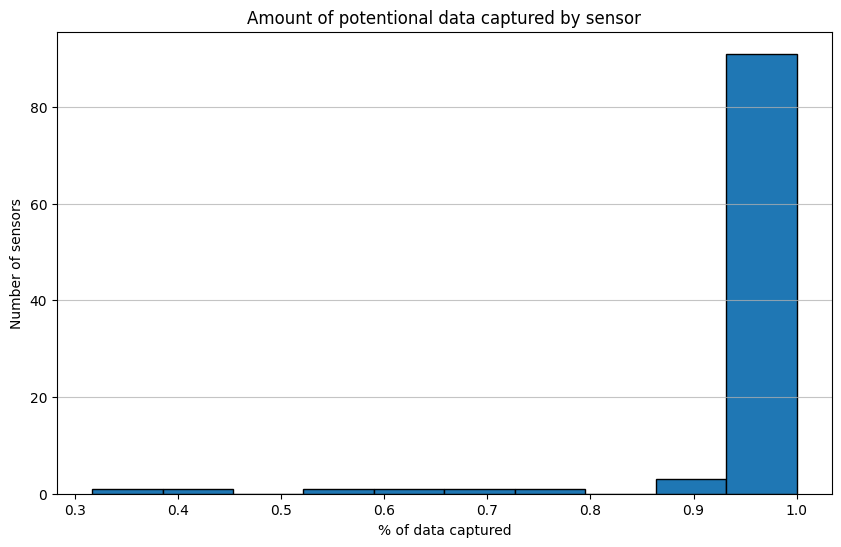

In [187]:
import matplotlib.pyplot as plt

# Create a histogram for 'Completeness %'
plt.figure(figsize=(10, 6))
plt.hist(df_grouped['completeness %'], bins=10, edgecolor='black')
plt.title('Amount of potentional data captured by sensor')
plt.xlabel('% of data captured')
plt.ylabel('Number of sensors')
plt.grid(axis='y', alpha=0.75)
plt.show()